In [6]:
#1导入库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['SimHei']

In [7]:
#2导入数据
df  = pd.read_csv('Merged_Chem.csv')
df.head()

,Unnamed: 0,Unique ID,NTS Sheet,Latitude_NAD83,Longitude_NAD83,Old Zn,Old Cu,Old Pb,Old Ni,Old Co,...,New Ti,New Tl,New Tm,New U,New V,New W,New Y,New Yb,New Zn,New Zr
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,013L781002,013L,54.989093,-62.019071,40.0,38.0,NaN,43.0,10.0,...,0.021,0.03,0.10,0.3,31.0,NaN,6.04,0.64,44.0,0.9
2,2,013L781003,013L,54.975382,-62.030577,40.0,44.0,NaN,35.0,8.0,...,0.021,0.03,0.08,0.3,45.0,NaN,5.65,0.49,45.1,1.0
3,3,013L781004,013L,54.976331,-62.044913,46.0,30.0,NaN,34.0,8.0,...,0.023,0.04,0.09,0.3,17.0,NaN,7.19,0.64,51.4,0.8
4,4,013L781005,013L,54.973541,-62.054790,50.0,26.0,NaN,22.0,6.0,...,0.014,0.03,0.12,0.6,34.0,NaN,8.08,0.74,51.1,0.8


In [8]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3442 entries, 0 to 3441
Data columns (total 88 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          3442 non-null   int64  
 1   Unique ID           3441 non-null   str    
 2   NTS Sheet           3441 non-null   str    
 3   Latitude_NAD83      3441 non-null   float64
 4   Longitude_NAD83     3441 non-null   float64
 5   Old Zn              3441 non-null   float64
 6   Old Cu              3441 non-null   float64
 7   Old Pb              2143 non-null   float64
 8   Old Ni              3438 non-null   float64
 9   Old Co              3416 non-null   float64
 10  Old Ag              606 non-null    float64
 11  Old Mn              3441 non-null   float64
 12  Old Fe              3441 non-null   float64
 13  Old As              799 non-null    float64
 14  Old Mo              2496 non-null   float64
 15  Old F               3433 non-null   float64
 16  LOI              

,Unnamed: 0,Latitude_NAD83,Longitude_NAD83,Old Zn,Old Cu,Old Pb,Old Ni,Old Co,Old Ag,Old Mn,...,New Ti,New Tl,New Tm,New U,New V,New W,New Y,New Yb,New Zn,New Zr
count,3442.00000,3441.000000,3441.000000,3441.000000,3441.000000,2143.000000,3438.000000,3416.000000,606.000000,3441.000000,...,3440.000000,3393.000000,3439.000000,3440.000000,3440.000000,2056.000000,3440.000000,3440.000000,3440.000000,3355.000000
mean,1720.50000,55.383663,-63.778378,111.829119,28.005522,3.614559,17.569226,10.814110,0.278053,662.333333,...,0.041443,0.138246,0.354181,3.464738,32.671221,0.438619,24.024858,2.199233,114.758692,1.785902
std,993.76414,0.853529,1.451083,104.297344,23.771434,2.526390,18.533247,11.908128,0.182716,3055.596946,...,0.030462,0.116209,0.391382,5.752473,18.434130,0.756015,24.319667,2.348694,104.044383,4.569569
min,0.00000,54.005243,-66.997815,14.000000,2.000000,2.000000,2.000000,2.000000,0.200000,10.000000,...,0.003000,0.020000,0.020000,0.100000,2.000000,0.100000,1.710000,0.150000,12.800000,0.100000
25%,860.25000,54.646363,-64.884206,62.000000,14.000000,2.000000,8.000000,5.000000,0.200000,95.000000,...,0.021000,0.070000,0.140000,0.900000,21.000000,0.200000,10.357500,0.880000,64.800000,0.300000
50%,1720.50000,55.238594,-63.316447,90.000000,22.000000,3.000000,12.000000,8.000000,0.200000,160.000000,...,0.033000,0.110000,0.230000,1.900000,30.000000,0.200000,16.460000,1.430000,94.100000,0.600000
75%,2580.75000,56.136332,-62.667055,132.000000,34.000000,4.000000,21.000000,12.000000,0.300000,350.000000,...,0.053000,0.170000,0.410000,4.000000,41.000000,0.500000,28.392500,2.590000,135.100000,1.500000
max,3441.00000,56.997959,-62.001419,2800.000000,355.000000,38.000000,290.000000,178.000000,1.800000,99999.000000,...,0.260000,1.870000,5.220000,130.100000,330.000000,18.400000,300.060000,30.030000,3046.000000,138.800000


In [12]:
#3数据预处理
#统计每一列的缺失值数量和缺失比例
null_counts = df.isnull().sum()
null_ratio = df.isnull().mean()
print(pd.DataFrame({'缺失数量':null_counts,'缺失比例':null_ratio}).sort_values(by='缺失比例',ascending=True).head(30))

                    缺失数量      缺失比例
Unnamed: 0             0  0.000000
Unique ID              1  0.000291
NTS Sheet              1  0.000291
Latitude_NAD83         1  0.000291
Longitude_NAD83        1  0.000291
Old Zn                 1  0.000291
Old Cu                 1  0.000291
Old Mn                 1  0.000291
Old Fe                 1  0.000291
Sample Type            1  0.000291
Latitude (NAD 27)      1  0.000291
Longitude (NAD 27)     1  0.000291
NTS                    1  0.000291
LOI                    1  0.000291
Old Hg                 1  0.000291
New Ag                 2  0.000581
New Ca                 2  0.000581
New Ba                 2  0.000581
New Al                 2  0.000581
New Hg                 2  0.000581
New Ho                 2  0.000581
New Gd                 2  0.000581
New Fe                 2  0.000581
New Eu                 2  0.000581
New Er                 2  0.000581
New Dy                 2  0.000581
New Cu                 2  0.000581
New Cs              

   Latitude_NAD83  Longitude_NAD83  New Al  New Ca  New Fe  New Cu  Old Zn
1       54.989093       -62.019071    2.89    0.48    1.06   43.46    40.0
2       54.975382       -62.030577    3.22    0.48    2.19   49.32    40.0
3       54.976331       -62.044913    2.34    0.56    0.75   33.34    46.0
4       54.973541       -62.054790    2.26    0.47    0.84   26.07    50.0
5       54.936983       -62.026399    1.89    0.55    0.75   21.40    42.0


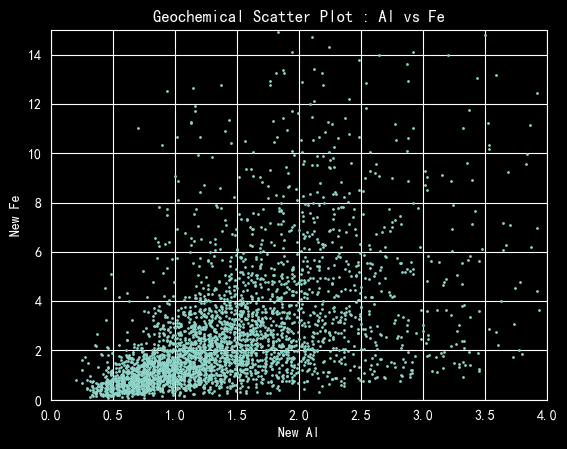

In [18]:
#提取数据质量好的几列
df_sub = df[['Latitude_NAD83','Longitude_NAD83','New Al','New Ca','New Fe','New Cu','Old Zn']]
#删除这几列有缺失值的行
df_sub = df_sub.dropna()
print(df_sub.head())
#绘制散点图 看铝铁的关系
df_sub.plot.scatter(x='New Al',
                    y='New Fe',
                    s= 1,
                    )
plt.xlabel('New Al')
plt.ylabel('New Fe')
plt.title('Geochemical Scatter Plot : Al vs Fe')
plt.xlim(0,4)
plt.ylim(0,15)
plt.savefig('Al_Fe_Scatter.png',dpi=300,bbox_inches='tight')
plt.show()